### Import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities


In [3]:
os.chdir("/home/bardia/graphical-sampling")

### Reading Data

In [4]:
dfs ={}
path = "/home/bardia/graphical-sampling/simulations/populations"
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n):
    for f in files:
        full_path = os.path.join(path, f)
        df = pd.read_csv(full_path)
        N = len(df)
        
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.iloc[:, :].to_numpy()
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,}
                )
        ##################################
        if f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            probs_up  = inclusion_probabilities(df['copper'].to_numpy(), n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['cadmium'], }
                )
        ###################################
        if f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5,100)
            probs_up  = inclusion_probabilities(AREA, n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['AREA_A'].to_numpy(), }
                )
        ####################################
    return(dfs)


In [62]:
popu = 'df_aggregated'
ep_or_up = 'pik_ep'
n = 20
num_zones_cluster = [4]
num_zones_sweep = [(2, 2)]
num_splits = [4]


### Random Population and Parameters

In [63]:

df = popus(n)[popu]
N = len(df)

coords = pd.DataFrame(df[['coord_x', 'coord_y']])
inclusions = df[ep_or_up]
variable = df['z'] if 'z' in df.columns else inclusions

pop = gs.Population(coords, inclusions, n=n, variable=variable)
fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)
# fbn.fit(pop)
# fbn.fit_zones(num_zones=(1, 1), mode='sweep_xy')
# fbn.plot(mode='hard')
print(popu)

df_aggregated


<Axes: title={'center': 'FIP Balanced 20-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

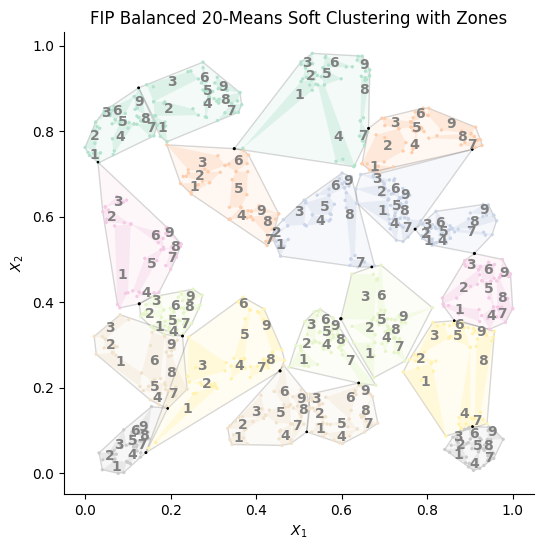

In [64]:
fbn.fit(pop)
fbn.fit_zones(num_zones=(3, 3), mode='sweep_xy')
fbn.plot(mode='soft')

### Pre-Process

In [65]:
initial_designs = []
point_strategies = [
      'lexico_yx', 'angle', 'dist_from_origin',
     'dist_from_centroids', 'max_coord',
    'spiral', None,
    'lexico_xy', 'projection',
]
point_strategies=['spiral']
zone_strategies = [
      'lexico_yx', 'dist_from_origin',
    'spiral', None,
    'lexico_xy', 'projection'
]
zone_strategies = ['spiral']
zone_modes = [
    'cluster', 'sweep_xy', 'sweep_yx'
]
# zone_modes = ['cluster']

track = []

num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)
min_moran = 0
for _ in range(1):
    
    for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
        product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
    ):
    
        if zone_mode == 'cluster':
            list_of_num_zones = num_zones_cluster
        else:
            list_of_num_zones = num_zones_sweep
    
        for num_zones in list_of_num_zones:
    
            for _ in range(1):
    
                fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)
                fbn.fit(pop)
                fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
    
                # try:
                order = gs.Order.from_clusters(
                    pop,
                    fbn.clusters,
                    point_strategy,
                    zone_strategy,
                    num_split
                )
    
                design = gs.Design.from_order(pop, order)
    
                initial_designs.append(design)
                moran = design.moran[0]
                if moran<min_moran:
                    print(point_strategy, zone_strategy, zone_mode, num_split)
                    print(moran)
                    
                    min_moran = moran
                track.append(
                    (moran, design, zone_strategy, point_strategy, zone_mode, num_zones)
                )
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:1]

 33%|████████████████████████████▎                                                        | 1/3 [00:02<00:05,  2.88s/it]

spiral spiral cluster 4
-0.19466972158777412


 67%|████████████████████████████████████████████████████████▋                            | 2/3 [00:04<00:02,  2.02s/it]

spiral spiral sweep_xy 4
-0.23997003836693215


100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:05<00:00,  1.88s/it]


[(-0.23997003836693215,
  'spiral',
  'spiral',
  'sweep_xy',
  (2, 2))]

In [66]:
z = sorted(track, key=lambda x: x[0], reverse=False)

initial_moran, initial_design, zs, ps, zm, nz = z[0]


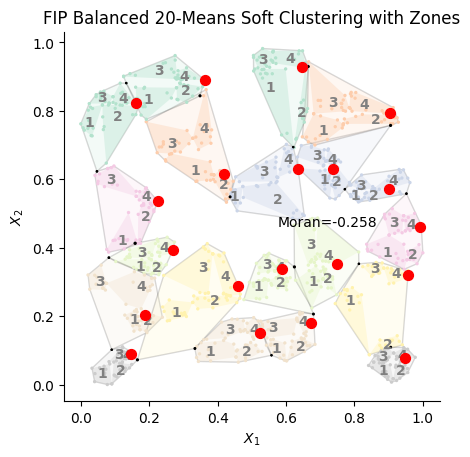

In [72]:
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

fig, ax = plt.subplots()

# background
fbn.plot(mode='soft', ax=ax)

# draw ONE sample

sample = gbfs.best_design.sample(1)   # shape (1, n)

coords = gbfs.best_design.pop.coords

# compute Moran
moran_index = Moran(gbfs.best_design.pop)
score = moran_index.score(sample)[0]

# plot sampled units
s = sample[0]
ax.scatter(coords[s,0], coords[s,1], color="red", s=50, zorder=10)

# label Moran value at sample centroid
x, y = coords[s].mean(axis=0)
ax.text(x, y, f"Moran={score:.3f}", fontsize=10)

plt.show()


In [31]:
srs_var = N**2 * (1-n/N) * np.var(variable)/n

plain_flat = [
    N,
    n,
    5000,
    0,
    np.sum(variable),
    initial_design.nht_variance,
    # srs_var / initial_design.nht_variance,
    0,
    0,
    initial_design.density_disparity[0],
    initial_design.density_disparity[1],
    initial_design.voronoi[0],
    initial_design.voronoi[1],
    initial_design.moran[0],
    initial_design.moran[1],
    initial_design.local_balance[0],
    initial_design.local_balance[1],
]

print(", ".join(map(str, plain_flat)))


999, 20, 5000, 0, 19.999999999999996, 0.0, 0, 0, 0.03029617736257209, 0.07431245079389422, 0.07789132723110151, 0.03823176400961267, -0.2525958231478811, 0.04275700028787704, 0.12976853608993916, 0.03798236516202982


In [36]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [37]:
import os
import pickle

save_dir_designs = "./simulations/best_design"
filename = f"initial_design_{popu}_{n}_{ep_or_up}.pkl"
filepath = os.path.join(save_dir_designs, filename)

mode = "save"   # "save" or "load"

if mode == "save":
    initial_design = gbfs.best_design
    with open(filepath, "wb") as f:
        pickle.dump(initial_design, f)

elif mode == "load":
    with open(filepath, "rb") as f:
        initial_design = pickle.load(f)

gbfs.best_designs = [initial_design]


### GRIZZLY

In [41]:

if 1==1:
    with open(filepath, "rb") as f:
        best_design = pickle.load(f)
        gbfs.initial_designs = [best_design]

In [42]:
gbfs.run(
    max_iterations=1000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=20,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=30,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,20),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1,4),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='default',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.75,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    n_jobs = 1
)


--- Starting Parallel GBFS: Max Iterations=1000, Batch Size=1, Workers=1 ---
Initial best criteria value: -0.2530
Iter     0/1000 | Best: -0.2530 | Open:     1 | Closed:     0
0: -0.2530991,  order_change,  DSize:1298,  var:0.00, Entp:6.75
1: -0.2533349,  order_change,  DSize:1298,  var:0.00, Entp:6.75
2: -0.2535192,  order_change,  DSize:1299,  var:0.00, Entp:6.75
2: -0.2535421,  order_change,  DSize:1298,  var:0.00, Entp:6.75
2: -0.2540149,  order_change,  DSize:1297,  var:0.00, Entp:6.75
3: -0.2543174,  order_change,  DSize:1296,  var:0.00, Entp:6.75
4: -0.2544391,  order_change,  DSize:1296,  var:0.00, Entp:6.75
5: -0.2544401,  order_change,  DSize:1298,  var:0.00, Entp:6.75
5: -0.2544576,  order_change,  DSize:1297,  var:0.00, Entp:6.75
5: -0.2544577,  order_change,  DSize:1297,  var:0.00, Entp:6.75
5: -0.2544890,  order_change,  DSize:1296,  var:0.00, Entp:6.75
6: -0.2545858,  order_change,  DSize:1296,  var:0.00, Entp:6.75
7: -0.2548684,  order_change,  DSize:1294,  var:0.00, En

KeyboardInterrupt: 

In [43]:

filename = f"best_design_{popu}_{n}_{ep_or_up}.pkl"
filepath = os.path.join(save_dir_designs, filename)

# save your design object
with open(filepath, "wb") as f:
    pickle.dump(gbfs.best_design, f)
gbfs.initial_designs = [gbfs.best_design]

In [ ]:
srs_var = N**2 * (1-n/N) * np.var(variable)/n
plain_flat = [
    N,
    n,
    5000,
    0,
    np.sum(variable),
    float(gbfs.best_design.nht_variance),
    float(srs_var / gbfs.best_design.nht_variance),
    0,
    *map(float, gbfs.best_design.density_disparity),
    *map(float, gbfs.best_design.voronoi),
    *map(float, gbfs.best_design.moran),
    *map(float, gbfs.best_design.local_balance),
]
arr = np.array(plain_flat, dtype=float)
simple = [float(x) for x in arr]
# Example: flatten all tuples in the list
flat = []
for x in simple:
    if isinstance(x, tuple):
        flat.extend(x)
    else:
        flat.append(x)

print(', '.join(str(x) for x in flat))




# Store

In [62]:
gbfs.best_design.pop.coords

array([[0.49993557, 0.0792481 ],
       [0.24947861, 0.41318937],
       [0.75039252, 0.74712864],
       ...,
       [0.65548937, 0.2789745 ],
       [0.40503242, 0.61291377],
       [0.90594633, 0.94685303]], shape=(999, 2))

In [53]:
ax = gbfs.best_design.pop


In [54]:
print(type(ax))


<class 'graphical_sampling.population.Population'>


In [56]:
gbfs.best_design.sample(1)

array([[961, 452, 967,  71, 400,  17, 658, 274, 594,  24, 218, 669, 543,
        101, 361,  44, 945,  51, 125, 767]])

<Axes: title={'center': 'FIP Balanced 20-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

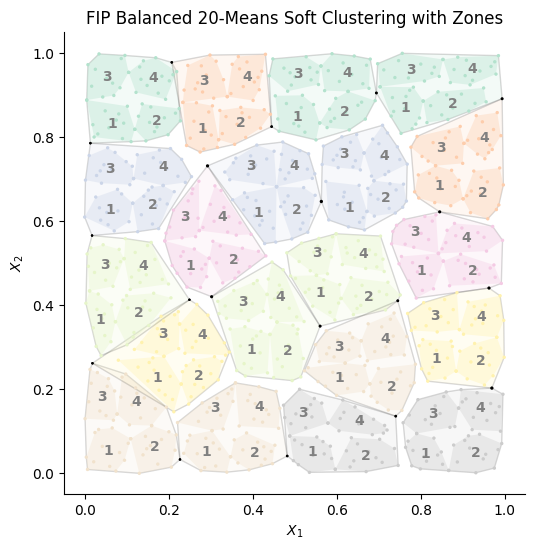

In [58]:
 fbn.plot(mode='soft')

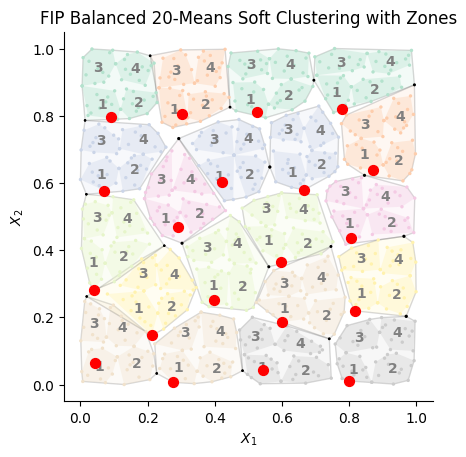

In [66]:
import matplotlib.pyplot as plt

# create figure and axis
fig, ax = plt.subplots()

# first layer: the background plot
fbn.plot(mode='soft', ax=ax)   # if the function supports ax

# sample one design point
sample = gbfs.best_design.sample(1)

# coordinates of the population
coords = gbfs.best_design.pop.coords

# scatter layer
ax.scatter(coords[sample, 0], coords[sample, 1], color='red', s=50, zorder=10)

plt.show()


In [47]:
# sumi = 0
# for i in gbfs.best_design.all_samples_and_probs[1]:
#     sumi += i
#     print(sumi)

In [ ]:
raise SystemExit("Stopping Run All: Archived cells below.")

In [ ]:
dir(gbfs.best_design)

In [ ]:

gbfs.best_design.entropy
len(gbfs.best_design.all_samples_and_probs[1])

gbfs.best_design.merge_identical()


print(len(gbfs.best_design.all_samples_and_probs[0]))

In [ ]:
gbfs.best_design